In [4]:
import kagglehub
import os
import shutil

target_dir = os.path.join(os.getcwd(), "dataset")
cache_path = kagglehub.dataset_download("jangedoo/utkface-new")

if not os.path.exists(target_dir) or not os.listdir(target_dir):
    os.makedirs(target_dir, exist_ok=True)
    
    for item in os.listdir(cache_path):
        s = os.path.join(cache_path, item)
        d = os.path.join(target_dir, item)
        
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy(s, d)
else:
    ...

c:\Users\TommasoBruzzese\Documents\esame_finale_dl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Visualizzazione immagini e relativi path

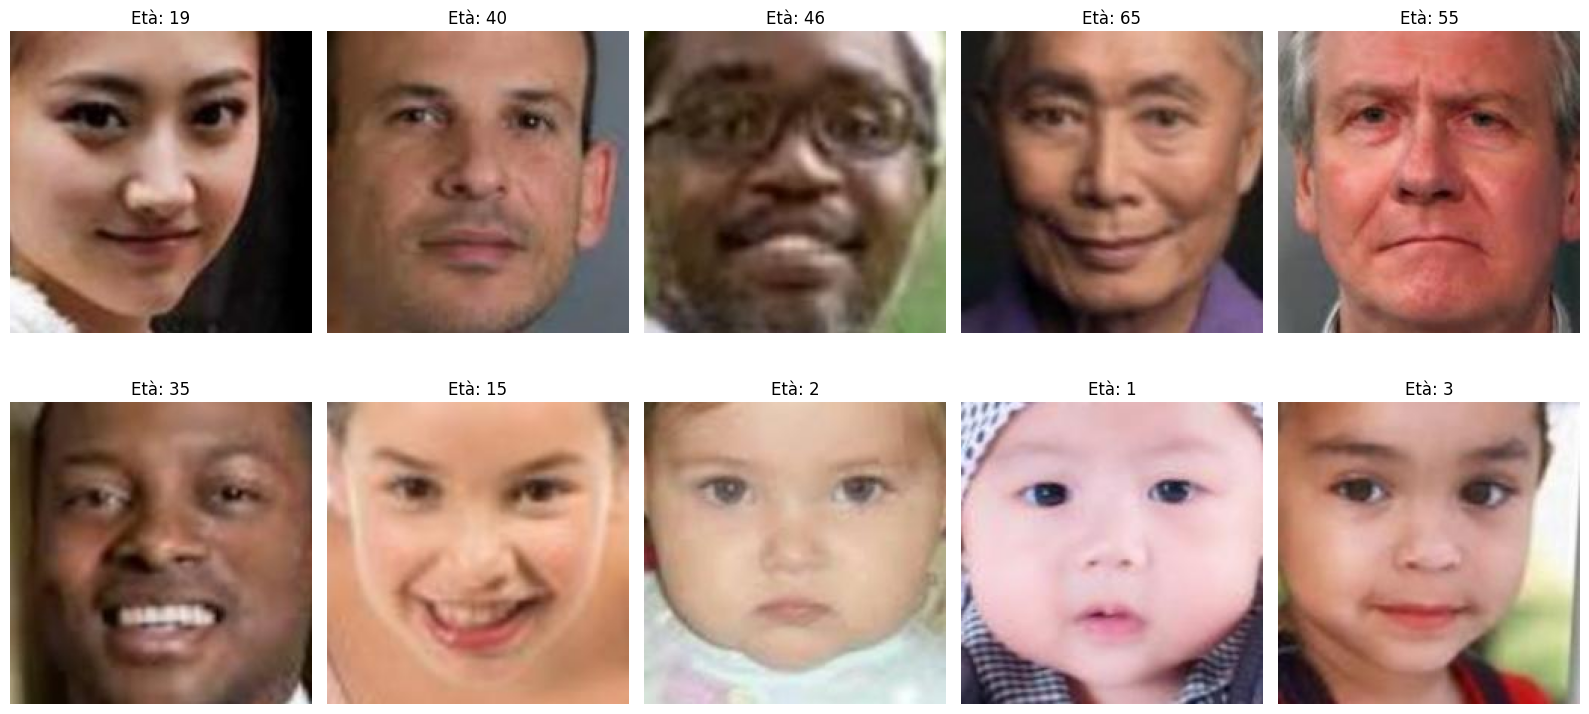

In [5]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

try:
    base_path = os.path.join('dataset', 'UTKFace') 
except NameError:
    base_path = os.path.join('utkface-new', 'versions', '1', 'UTKFace')

if not os.path.exists(base_path):
    base_path = 'UTKFace'
    if not os.path.exists(base_path):
        raise FileNotFoundError("Nessun percorso valido trovato per la cartella UTKFace.")

files = [f for f in os.listdir(base_path) if f.endswith('.jpg')]
data = []

for f in files:
    parts = f.split('_')
    if len(parts) >= 3:
        try:
            age = int(parts[0])
            gender = int(parts[1])
            full_path = os.path.join(base_path, f)
            data.append({'path': full_path, 'age': age, 'gender': gender})
        except ValueError:
            continue

df = pd.DataFrame(data)

plt.figure(figsize=(16, 8))
sample_indices = random.sample(range(len(df)), 10)

for i, idx in enumerate(sample_indices):
    img_path = df['path'].iloc[idx]
    age_target = df['age'].iloc[idx]
    img = Image.open(img_path)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Età: {age_target}")
    plt.axis('off')

plt.tight_layout()
plt.show()   

# Augmentation (albumentation)

In [6]:
import albumentations
import numpy as np
from tqdm import tqdm

transform = albumentations.Compose([
    # ridimensionamento
    albumentations.Resize(height=64, width=64),
    
    # augmentation per maggiore precisione
    albumentations.HorizontalFlip(p=0.5),
    albumentations.RandomBrightnessContrast(p=0.2),
    albumentations.Rotate(limit=15, p=0.5),
    albumentations.GaussNoise(p=0.1),
    
    # normalizzazione
    albumentations.Normalize(mean=(0.5,), std=(0.5,)) 
])

## Applicazione della data augmentation su dataset

In [19]:
def process_image_for_training(image_path):
    with Image.open(image_path) as img:
        img_rgb = img.convert("RGB")
        image_np = np.array(img_rgb)
    
    augmented = transform(image=image_np)
    image_final = augmented["image"]
    
    return image_final

test_batch = process_image_for_training(df['path'].iloc[0])
print(f"Shape finale per la rete: {test_batch.shape}") 

Shape finale per la rete: (64, 64, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980393..0.97647065].


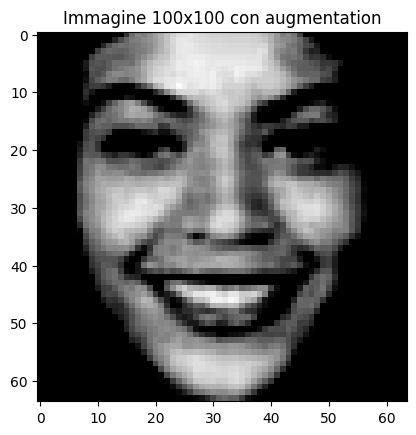

In [55]:
#verifica della data augmentation
img_transformed = process_image_for_training(df['path'].iloc[1000])

plt.imshow(img_transformed)
plt.title("Immagine 100x100 con augmentation")
plt.show()

In [22]:
def prepara_dataset(dataframe, transform_pipeline):
    '''
    la funzione prepara il dataset di immagini e le trasforma in formato "digeribile dalla rete"

    Args:
        dataframe (pandas.DataFrame): il DataFrame contenente i metadati del dataset. 
            Deve obbligatoriamente includere due colonne:
            - 'path': (str) il percorso assoluto o relativo del file immagine su disco.
            - 'age': (int o float) il valore target (età) da prevedere.
        transform_pipeline (albumentations.Compose): la pipeline di funzioni di 
            trasformazione della libreria Albumentations da applicare a ogni immagine 
            (es. Resize, HorizontalFlip, Normalize).

    Returns:
        - X: Un array multidimensionale contenente i tensori di 
             tutte le immagini elaborate con successo trasformate in np array. 
             Shape tipica: (numero_immagini, altezza, larghezza, canali).
        - y: Un array monodimensionale contenente i target (età) 
             corrispondenti. Shape tipica: (numero_immagini,).
    '''

    X = []
    y = []
    
    for index, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        try:
            with Image.open(row['path']) as img:
                img_rgb = img.convert("RGB")
                img_np = np.array(img_rgb)
            
            augmented = transform_pipeline(image=img_np)
            img_final = augmented["image"]
            
            X.append(img_final)
            y.append(row['age'])
            
        except Exception as e:
            print(f"Errore sull'immagine {row['path']}: {e}")
            continue
            
    return np.array(X), np.array(y)

X, y = prepara_dataset(df, transform)

print(f"\nTrasformazione completata!")
print(f"Forma di X (Immagini): {X.shape}")
print(f"Forma di y (Target): {y.shape}")

100%|██████████| 23708/23708 [00:44<00:00, 527.46it/s]



Trasformazione completata!
Forma di X (Immagini): (23708, 64, 64, 3)
Forma di y (Target): (23708,)


# Addestramento Rete

## Creazione del train e test set

In [ ]:
from sklearn.model_selection import train_test_split

#dividiamo il dataset in train e test img e relativi target
#diamo un test size del 20% (standard)
#un seme di generazione randomico standard per le reti
#e applichiamo la shuffle esegue il rimescolamento del train e del test per prevenire overfitting o evitare dati ordinati

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    shuffle=True)

print(f"Train set: {X_train.shape[0]} immagini")
print(f"Test set: {X_test.shape[0]} immagini")

Train set: 18966 immagini
Test set: 4742 immagini


In [ ]:
from keras import Sequential, Input
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.metrics import MeanAbsoluteError
from keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard, CSVLogger

#creazione della CNN

model = Sequential([
    Input(shape=(64, 64, 3)),
    
    # blocco 1: estrazione base
        # nella Conv2D usiamo 32 filtri per cercare cose basi (linee verticali, linee orizzontali, bordi)
        # la BatchNormalization lo usiamo per rendere l'addestramento molto più veloce e sicuro per stabilizzare i valori in caso sballino troppo.
        # con la MaxPooling2D tieniamo solo il segnale più forte presente nel 
        # vetore questo dimmezza la dimensione dlel'immagine nel prossimo blocco (32x32)
        # il dropout lo usiamo per evitare che la rete non si abitui e che ogni dettaglio venga categorizzato
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2), # Iniziamo a disturbare leggermente il segnale
    
    # blocco 2: dettagli medi
        # nella Conv2D usiamo 64 filtri per cercare le forme (cerchi, curve, un occhio, un naso)
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    
    # blocco 3: caratteristiche complesse
        # nella Conv2D usiamo 128 filtri per cercare concetti complessi (un viso intero, occhiaie, rughe)
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3), # dropout più alto man mano che i filtri aumentano
    
    # questo riduce i parametri drasticamente e combatte l'overfitting
        # prende ogni singolo filtro nel nostro caso 128 e fa la media matematica di tutti i suoi pixel, 
        # facendolo diventare un solo numero.
    GlobalAveragePooling2D(),
    
    # dense è uno strato classico in cui 128 neuroni prendono le informazioni estratte prima e cercano di metterle insieme
    Dense(128, activation='relu'),
    Dropout(0.5), # mettiamo l'ultimo deopout che spegne il 50% dei neuroni prima della risposta finale
    
    # infine usiamo la linear per dare in output l'età imparata
    Dense(1, activation='linear') 
])

In [ ]:
model.compile(
    #usiamo come ottimizzatore adam con il learning rate standard
    optimizer=Adam(learning_rate=1e-3),
    #la Loss (mse) è la funzione che la rete neurale cerca attivamente di minimizzare. 
    #è ciò che guida l'aggiornamento dei pesi.
        #prende la differenza tra l'età reale e quella prevista, e la eleva al quadrato.
    loss=MeanSquaredError(),
    # la metrica serve per capire come sta andando il modello.
    metrics=[MeanAbsoluteError()]
)

In [ ]:
#in questa parte creiamo la directory per salvare i log di keras per fare i confronti sulla tensorboard
os.makedirs("keras/logs", exist_ok=True)
exp = "shape_64x64_con_droput_aggiornati_e_GlobalAveragePooling2D"
callbacks = [
    ModelCheckpoint(filepath="keras/checkpoint-{epoch:02d}-{val_loss:.2f}.keras"),
    CSVLogger("keras/trainining.log"),
    TensorBoard(f"keras/logs/{exp}"),
    # l'EarlyStopping serve per fermare l'addestramento in caso non migliori e la pazienza serve a dire 
    # dopo quanto si deve fermare da quando è stabile e il restore_best_weights lo mettiamo a true per tornare alla miglior epoca 
    # dopo la fine dell'addestramento
    EarlyStopping(patience=10, 
                  restore_best_weights=True)
]


In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [28]:
#fittiamo il modello e iniziamo l'addestramento
model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    #la batch size è la quantità di immagini che prendiamo in esame per l'addestramento
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 68s 110ms/step - loss: 374.2311 - mean_absolute_error: 14.7196 - val_loss: 436.6938 - val_mean_absolute_error: 16.6458
Epoch 2/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 66s 111ms/step - loss: 278.5048 - mean_absolute_error: 12.7835 - val_loss: 239.0556 - val_mean_absolute_error: 11.6578
Epoch 3/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 68s 115ms/step - loss: 252.4914 - mean_absolute_error: 12.1060 - val_loss: 221.7639 - val_mean_absolute_error: 11.5211
Epoch 4/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 69s 117ms/step - loss: 233.7300 - mean_absolute_error: 11.6058 - val_loss: 352.6447 - val_mean_absolute_error: 14.4473
Epoch 5/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 65s 110ms/step - loss: 220.4714 - mean_absolute_error: 11.2099 - val_loss: 186.3180 - val_mean_absolute_error: 10.4039
Epoch 6/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 64s 107ms/step - loss: 205.0380 - mean_absolute_error: 10.8144 - val_loss: 168.6426 - val_mean_absolute_error: 9.7990
Epoch 7/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 